# 🧠 Building a RAG Pipeline for LLMs

**Retrieval-Augmented Generation (RAG)** enhances Large Language Models by grounding their answers in retrieved, real-world knowledge — reducing hallucinations and keeping responses factually accurate.

### Pipeline Architecture
```
User Question
     │
     ▼
┌─────────────┐     ┌──────────────────┐     ┌────────────────┐
│  Retriever   │────▶│   Vector Store    │────▶│   Generator    │
│ (Wikipedia)  │     │ (FAISS + SentTF)  │     │ (RoBERTa QA)   │
└─────────────┘     └──────────────────┘     └────────────────┘
     │                      │                        │
  Fetch &               Embed &                 Extract
  Chunk text           Similarity Search         Answer
```

### What This Notebook Covers
| Step | Component | Description |
|------|-----------|-------------|
| 1 | **Setup** | Install dependencies & configure parameters |
| 2 | **Retriever** | Fetch Wikipedia content & chunk it into tokens |
| 3 | **Vector Store** | Embed chunks with SentenceTransformer & index with FAISS |
| 4 | **Generator** | Load QA model & extract answers from context |
| 5 | **Full Pipeline** | End-to-end RAG: ingest → retrieve → answer |
| 6 | **Visualization** | Embedding space, chunk distributions, retrieval distances |
| 7 | **Validation** | Multi-question evaluation with accuracy, confidence & error analysis |

---
## Step 1: Setup & Configuration

In [1]:
# Install required packages (uncomment if running for the first time)
!pip install wikipedia transformers sentence-transformers faiss-cpu torch numpy matplotlib scikit-learn seaborn tf-keras

In [1]:
# ============================================================
# Imports
# ============================================================
import time
import warnings
warnings.filterwarnings("ignore")

import wikipedia
import numpy as np
import faiss
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from transformers import AutoTokenizer, AutoModelForQuestionAnswering
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Plotting style
sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

print("✅ All imports successful!")
print(f"   PyTorch version : {torch.__version__}")
print(f"   FAISS version   : {faiss.__version__}")
print(f"   Device          : {'CUDA' if torch.cuda.is_available() else 'CPU'}")


✅ All imports successful!
   PyTorch version : 2.7.1+cpu
   FAISS version   : 1.13.2
   Device          : CPU


In [3]:
# ============================================================
# Configuration — All tunable parameters in one place
# ============================================================
EMBEDDING_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"
QA_MODEL_NAME        = "deepset/roberta-base-squad2"

CHUNK_SIZE    = 256   # tokens per chunk
CHUNK_OVERLAP = 20    # overlapping tokens between consecutive chunks
TOP_K         = 3     # number of chunks to retrieve per query

# Topic to build our knowledge base from
TOPIC = "Cloud computing"

print("⚙️  Configuration")
print(f"   Embedding model : {EMBEDDING_MODEL_NAME}")
print(f"   QA model        : {QA_MODEL_NAME}")
print(f"   Chunk size      : {CHUNK_SIZE} tokens")
print(f"   Chunk overlap   : {CHUNK_OVERLAP} tokens")
print(f"   Top-K retrieval : {TOP_K}")
print(f"   Topic           : {TOPIC}")

⚙️  Configuration
   Embedding model : sentence-transformers/all-mpnet-base-v2
   QA model        : deepset/roberta-base-squad2
   Chunk size      : 256 tokens
   Chunk overlap   : 20 tokens
   Top-K retrieval : 3
   Topic           : Cloud computing


---
## Step 2: Knowledge Retrieval (Wikipedia)

We fetch the full text of a Wikipedia article for the chosen topic. The retriever uses **fallback strategies** — if a direct page lookup fails, it searches Wikipedia and tries the top results.

In [6]:
# ============================================================
# 2a. Fetch Wikipedia content
# ============================================================
def get_wikipedia_content(topic):
    """Fetch Wikipedia article content with fallback strategies."""
    # Strategy 1: Direct lookup
    try:
        page = wikipedia.page(topic, auto_suggest=True)
        print(f"✅ Found page: '{page.title}'")
        return page.content, page.title
    except wikipedia.exceptions.PageError:
        pass
    except wikipedia.exceptions.DisambiguationError as e:
        print(f"⚠️  Ambiguous topic. Trying first option: '{e.options[0]}'")
        try:
            page = wikipedia.page(e.options[0], auto_suggest=False)
            return page.content, page.title
        except Exception:
            pass

    # Strategy 2: Search and try top results
    print(f"🔍 Searching Wikipedia for '{topic}'...")
    search_results = wikipedia.search(topic, results=5)
    for result_title in search_results:
        try:
            page = wikipedia.page(result_title, auto_suggest=False)
            print(f"✅ Found page via search: '{page.title}'")
            return page.content, page.title
        except (wikipedia.exceptions.PageError,
                wikipedia.exceptions.DisambiguationError):
            continue

    raise RuntimeError(f"Could not retrieve content for '{topic}'")


document, page_title = get_wikipedia_content(TOPIC)
print(f"\n📄 Document length : {len(document):,} characters")
print(f"📄 Word count      : {len(document.split()):,} words")
print(f"\n--- First 500 characters ---\n{document[:500]}...")

✅ Found page: 'Cloud computing'

📄 Document length : 38,745 characters
📄 Word count      : 5,571 words

--- First 500 characters ---
Cloud computing is defined by the International Organization for Standardization (ISO) as "a paradigm for enabling network access to a scalable and elastic pool of shareable physical or virtual resources with self-service provisioning and administration on demand". It is commonly referred to as "the cloud".


== Characteristics ==
In 2011, the National Institute of Standards and Technology (NIST) identified five "essential characteristics" for cloud systems. Below are the exact definitions accor...


In [8]:
# ============================================================
# 2b. Chunking — split text into overlapping token-based chunks
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)

def split_text(text, chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP):
    """Split text into overlapping token-based chunks."""
    tokens = tokenizer.tokenize(text)
    chunks = []
    start = 0

    while start < len(tokens):
        end = min(start + chunk_size, len(tokens))
        chunk_text = tokenizer.convert_tokens_to_string(tokens[start:end])
        chunks.append(chunk_text)
        if end == len(tokens):
            break
        start = end - chunk_overlap

    return chunks, tokens


chunks, all_tokens = split_text(document)

print(f"📊 Chunking Results")
print(f"   Total tokens     : {len(all_tokens):,}")
print(f"   Number of chunks : {len(chunks)}")
print(f"   Chunk size       : {CHUNK_SIZE} tokens")
print(f"   Chunk overlap    : {CHUNK_OVERLAP} tokens")

Token indices sequence length is longer than the specified maximum sequence length for this model (7343 > 512). Running this sequence through the model will result in indexing errors


📊 Chunking Results
   Total tokens     : 7,343
   Number of chunks : 32
   Chunk size       : 256 tokens
   Chunk overlap    : 20 tokens


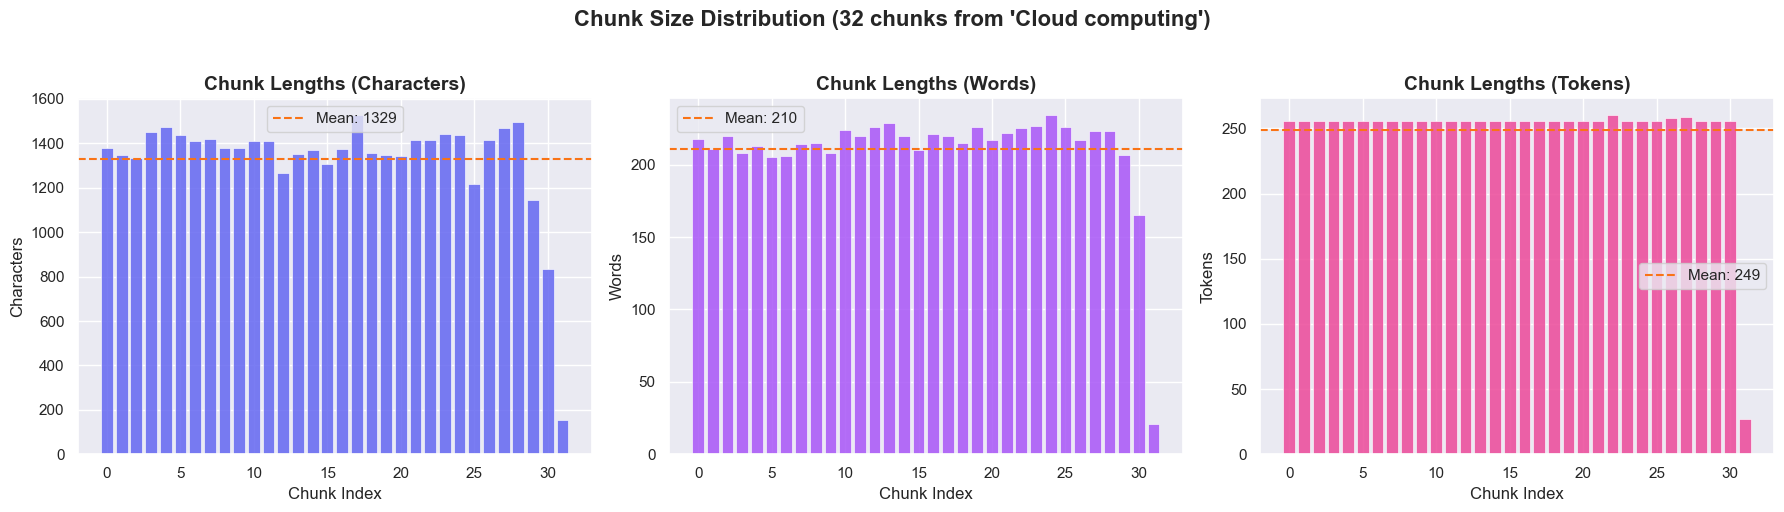


📊 Chunk Statistics
Metric               Characters      Words           Tokens         
─────────────────────────────────────────────────────────────────
Min                  152.0           21.0            27.0           
Max                  1526.0          234.0           260.0          
Mean                 1328.8          210.5           249.1          
Std Dev              243.9           36.0            39.9           


In [10]:
# ============================================================
# 📊 Visualization: Chunk length distribution
# ============================================================
chunk_lengths_chars = [len(c) for c in chunks]
chunk_lengths_words = [len(c.split()) for c in chunks]
chunk_lengths_tokens = [len(tokenizer.tokenize(c)) for c in chunks]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ["#6366f1", "#a855f7", "#ec4899"]

axes[0].bar(range(len(chunks)), chunk_lengths_chars, color=colors[0], alpha=0.85, edgecolor="white", linewidth=0.5)
axes[0].set_title("Chunk Lengths (Characters)", fontweight="bold")
axes[0].set_xlabel("Chunk Index")
axes[0].set_ylabel("Characters")
axes[0].axhline(y=np.mean(chunk_lengths_chars), color="#f97316", linestyle="--", label=f"Mean: {np.mean(chunk_lengths_chars):.0f}")
axes[0].legend()

axes[1].bar(range(len(chunks)), chunk_lengths_words, color=colors[1], alpha=0.85, edgecolor="white", linewidth=0.5)
axes[1].set_title("Chunk Lengths (Words)", fontweight="bold")
axes[1].set_xlabel("Chunk Index")
axes[1].set_ylabel("Words")
axes[1].axhline(y=np.mean(chunk_lengths_words), color="#f97316", linestyle="--", label=f"Mean: {np.mean(chunk_lengths_words):.0f}")
axes[1].legend()

axes[2].bar(range(len(chunks)), chunk_lengths_tokens, color=colors[2], alpha=0.85, edgecolor="white", linewidth=0.5)
axes[2].set_title("Chunk Lengths (Tokens)", fontweight="bold")
axes[2].set_xlabel("Chunk Index")
axes[2].set_ylabel("Tokens")
axes[2].axhline(y=np.mean(chunk_lengths_tokens), color="#f97316", linestyle="--", label=f"Mean: {np.mean(chunk_lengths_tokens):.0f}")
axes[2].legend()

plt.suptitle(f"Chunk Size Distribution ({len(chunks)} chunks from '{page_title}')", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Print statistics table
print("\n📊 Chunk Statistics")
print(f"{'Metric':<20} {'Characters':<15} {'Words':<15} {'Tokens':<15}")
print("─" * 65)
for label, data in [("Min", np.min), ("Max", np.max), ("Mean", np.mean), ("Std Dev", np.std)]:
    print(f"{label:<20} {data(chunk_lengths_chars):<15.1f} {data(chunk_lengths_words):<15.1f} {data(chunk_lengths_tokens):<15.1f}")

---
## Step 3: Vector Store (Embeddings + FAISS Index)

We convert each text chunk into a 768-dimensional embedding using the **Sentence Transformer** (`all-mpnet-base-v2`) model, then store them in a **FAISS** index for fast similarity search.

In [13]:
# ============================================================
# 3a. Load the embedding model & encode all chunks
# ============================================================
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

print(f"🔄 Encoding {len(chunks)} chunks...")
start_time = time.time()
embeddings = embedding_model.encode(chunks, show_progress_bar=True)
embeddings = np.array(embeddings, dtype="float32")
encoding_time = time.time() - start_time

print(f"\n✅ Encoding complete!")
print(f"   Embedding shape  : {embeddings.shape}  ({embeddings.shape[0]} chunks × {embeddings.shape[1]} dimensions)")
print(f"   Encoding time    : {encoding_time:.2f}s")
print(f"   Time per chunk   : {encoding_time / len(chunks) * 1000:.1f}ms")
print(f"   Memory usage     : {embeddings.nbytes / 1024:.1f} KB")

🔄 Encoding 32 chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Encoding complete!
   Embedding shape  : (32, 768)  (32 chunks × 768 dimensions)
   Encoding time    : 52.03s
   Time per chunk   : 1625.8ms
   Memory usage     : 96.0 KB


In [14]:
# ============================================================
# 3b. Build the FAISS index
# ============================================================
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)

print(f"✅ FAISS index built!")
print(f"   Index type       : IndexFlatL2 (exact L2 / Euclidean distance)")
print(f"   Vectors stored   : {index.ntotal}")
print(f"   Dimensions       : {dimension}")

✅ FAISS index built!
   Index type       : IndexFlatL2 (exact L2 / Euclidean distance)
   Vectors stored   : 32
   Dimensions       : 768


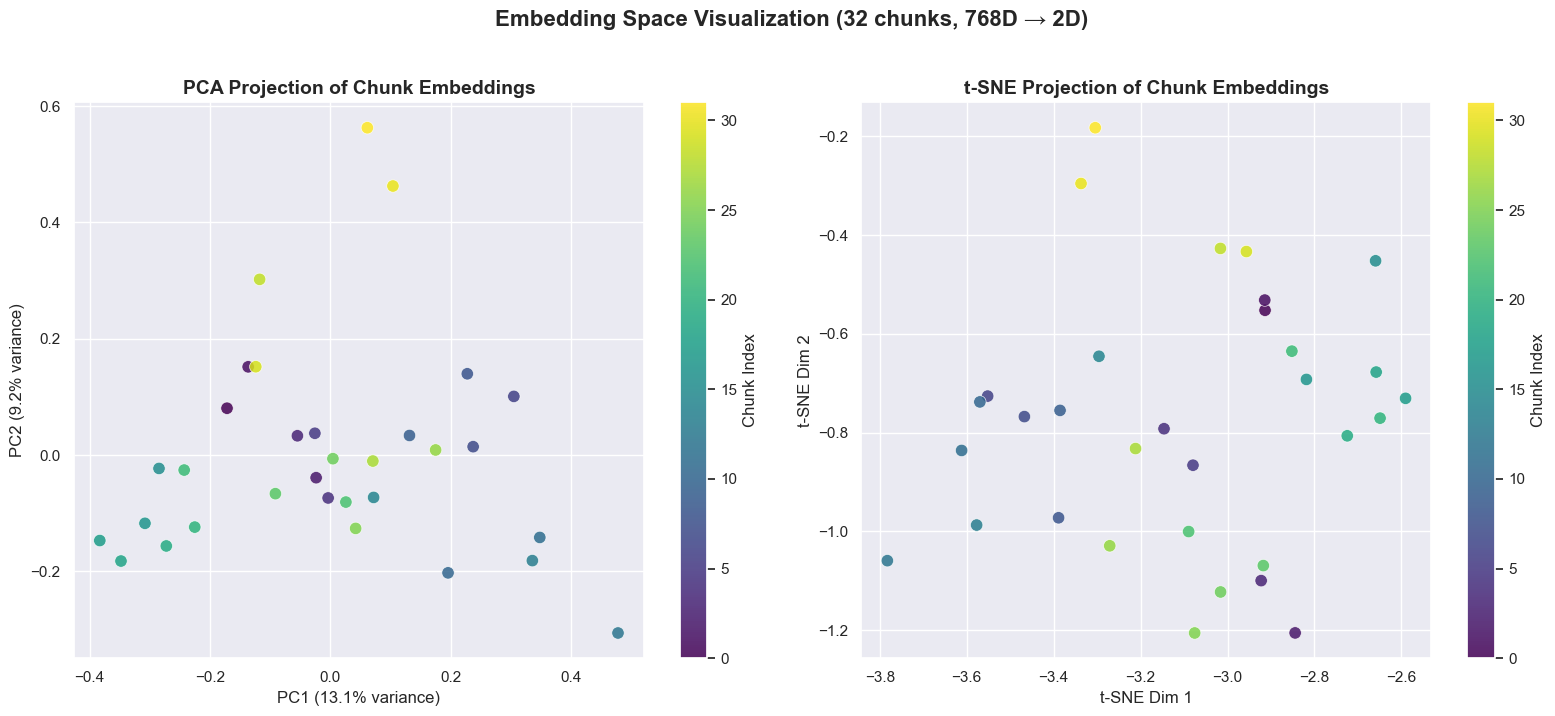


📊 PCA Explained Variance : 22.2% (first 2 components)


In [15]:
# ============================================================
# 📊 Visualization: Embedding space with PCA & t-SNE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Color by chunk position (early = blue, late = red)
colors_map = plt.cm.viridis(np.linspace(0, 1, len(chunks)))

# --- PCA ---
pca = PCA(n_components=2)
emb_pca = pca.fit_transform(embeddings)

sc1 = axes[0].scatter(emb_pca[:, 0], emb_pca[:, 1], c=range(len(chunks)),
                       cmap="viridis", s=80, edgecolors="white", linewidth=0.5, alpha=0.85)
axes[0].set_title("PCA Projection of Chunk Embeddings", fontweight="bold")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.colorbar(sc1, ax=axes[0], label="Chunk Index")

# --- t-SNE ---
perplexity = min(30, len(chunks) - 1)
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, n_iter=1000)
emb_tsne = tsne.fit_transform(embeddings)

sc2 = axes[1].scatter(emb_tsne[:, 0], emb_tsne[:, 1], c=range(len(chunks)),
                       cmap="viridis", s=80, edgecolors="white", linewidth=0.5, alpha=0.85)
axes[1].set_title("t-SNE Projection of Chunk Embeddings", fontweight="bold")
axes[1].set_xlabel("t-SNE Dim 1")
axes[1].set_ylabel("t-SNE Dim 2")
plt.colorbar(sc2, ax=axes[1], label="Chunk Index")

plt.suptitle(f"Embedding Space Visualization ({len(chunks)} chunks, {dimension}D → 2D)",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📊 PCA Explained Variance : {sum(pca.explained_variance_ratio_)*100:.1f}% (first 2 components)")

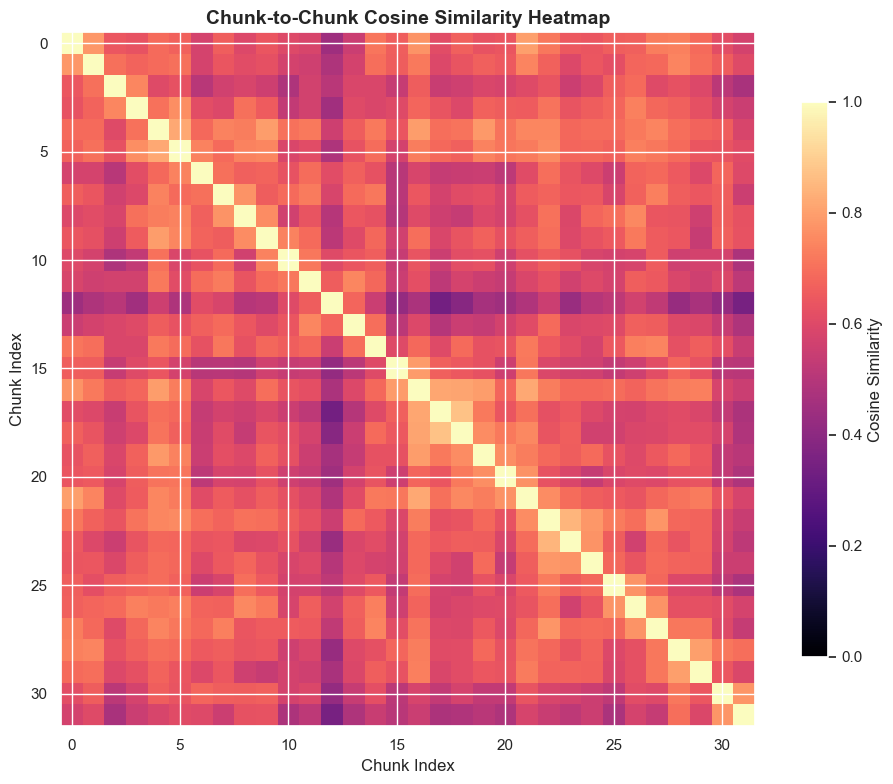


📊 Cosine Similarity Statistics (upper triangle, excluding diagonal):
   Mean     : 0.6319
   Std Dev  : 0.0808
   Min      : 0.3373
   Max      : 0.8730
   Median   : 0.6343


In [16]:
# ============================================================
# 📊 Visualization: Cosine similarity heatmap between chunks
# ============================================================
# Normalize embeddings to unit vectors for cosine similarity
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings_normalized = embeddings / norms
cosine_sim_matrix = embeddings_normalized @ embeddings_normalized.T

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cosine_sim_matrix, cmap="magma", vmin=0, vmax=1)
ax.set_title(f"Chunk-to-Chunk Cosine Similarity Heatmap", fontweight="bold", fontsize=14)
ax.set_xlabel("Chunk Index")
ax.set_ylabel("Chunk Index")
plt.colorbar(im, ax=ax, label="Cosine Similarity", shrink=0.8)
plt.tight_layout()
plt.show()

# Statistics
upper_triangle = cosine_sim_matrix[np.triu_indices_from(cosine_sim_matrix, k=1)]
print(f"\n📊 Cosine Similarity Statistics (upper triangle, excluding diagonal):")
print(f"   Mean     : {np.mean(upper_triangle):.4f}")
print(f"   Std Dev  : {np.std(upper_triangle):.4f}")
print(f"   Min      : {np.min(upper_triangle):.4f}")
print(f"   Max      : {np.max(upper_triangle):.4f}")
print(f"   Median   : {np.median(upper_triangle):.4f}")

---
## Step 4: Retrieval — Querying the FAISS Index

When a user asks a question, we:
1. Encode the question into an embedding (same model).
2. Search the FAISS index for the **top-k** most similar chunks.
3. Return the matching chunks as context for the QA model.

In [18]:
# ============================================================
# 4a. Retrieval function
# ============================================================
def retrieve(query, top_k=TOP_K):
    """Retrieve the top-k most relevant chunks for a query."""
    query_embedding = embedding_model.encode([query])
    query_embedding = np.array(query_embedding, dtype="float32")

    distances, indices = index.search(query_embedding, top_k)

    results = []
    for dist, idx in zip(distances[0], indices[0]):
        if idx < len(chunks):
            results.append({
                "chunk_index": int(idx),
                "chunk": chunks[idx],
                "distance": float(dist),
            })
    return results


# Test the retrieval with a sample question
test_query = "What is cloud computing?"
results = retrieve(test_query)

print(f"🔍 Query: \"{test_query}\"")
print(f"   Retrieved {len(results)} chunks:\n")
for i, r in enumerate(results):
    print(f"   📄 Chunk #{r['chunk_index']} (L2 distance: {r['distance']:.4f})")
    print(f"      {r['chunk'][:200]}...\n")

🔍 Query: "What is cloud computing?"
   Retrieved 3 chunks:

   📄 Chunk #28 (L2 distance: 0.5301)
      creating a scalable system of multiple independent computing devices, idle computing resources can be allocated and used more efficiently. virtualization provides the agility required to speed up it o...

   📄 Chunk #29 (L2 distance: 0.6410)
      or near - user edge devices, such as network routers. furthermore, fog computing handles data at the network level, on smart devices and on the end - user client - side ( e. g. mobile devices ), inste...

   📄 Chunk #0 (L2 distance: 0.6620)
      cloud computing is defined by the international organization for standardization ( iso ) as " a paradigm for enabling network access to a scalable and elastic pool of shareable physical or virtual res...



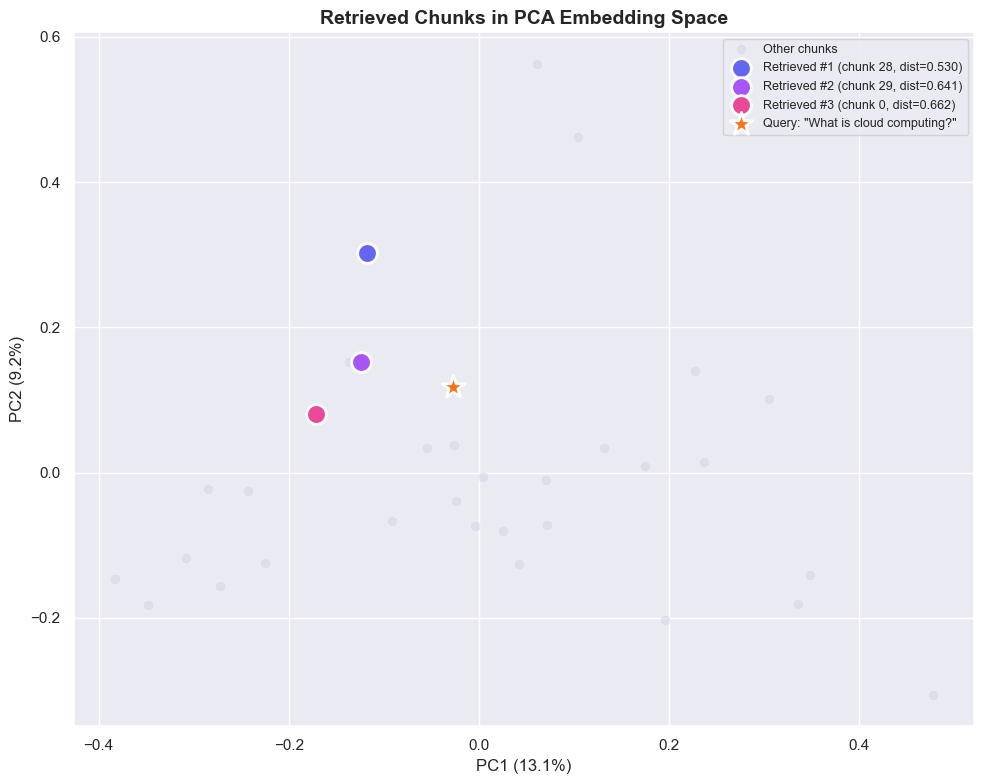

In [19]:
# ============================================================
# 📊 Visualization: Retrieved chunks highlighted in embedding space
# ============================================================
query_embedding_2d = pca.transform(embedding_model.encode([test_query]).astype("float32"))
retrieved_indices = [r["chunk_index"] for r in results]

fig, ax = plt.subplots(figsize=(10, 8))

# All chunks (grey)
ax.scatter(emb_pca[:, 0], emb_pca[:, 1], c="#cbd5e1", s=60, alpha=0.5, label="Other chunks", edgecolors="white", linewidth=0.5)

# Retrieved chunks (highlighted)
for i, idx in enumerate(retrieved_indices):
    ax.scatter(emb_pca[idx, 0], emb_pca[idx, 1], c=["#6366f1", "#a855f7", "#ec4899"][i % 3],
               s=200, zorder=5, edgecolors="white", linewidth=2,
               label=f"Retrieved #{i+1} (chunk {idx}, dist={results[i]['distance']:.3f})")

# Query point
ax.scatter(query_embedding_2d[:, 0], query_embedding_2d[:, 1], c="#f97316", s=300,
           marker="*", zorder=6, edgecolors="white", linewidth=2, label=f'Query: "{test_query}"')

ax.set_title("Retrieved Chunks in PCA Embedding Space", fontweight="bold", fontsize=14)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

---
## Step 5: Answer Generation (QA Model)

We load a pre-trained **extractive QA model** (`deepset/roberta-base-squad2`) that reads the retrieved context and extracts the most relevant answer span.

Key design details:
- **SQuAD 2.0 null-answer handling**: The model can predict "no answer" — we find the best *non-null* span and compare its score against the null score.
- **Sliding window**: For long contexts exceeding 512 tokens, we split into overlapping windows and pick the best answer.

In [21]:
# ============================================================
# 5a. Load the QA model
# ============================================================
qa_tokenizer = AutoTokenizer.from_pretrained(QA_MODEL_NAME)
qa_model = AutoModelForQuestionAnswering.from_pretrained(QA_MODEL_NAME)
qa_model.eval()

print(f"✅ QA Model loaded: {QA_MODEL_NAME}")
print(f"   Model parameters : {sum(p.numel() for p in qa_model.parameters()):,}")
print(f"   Max input length : 512 tokens")

✅ QA Model loaded: deepset/roberta-base-squad2
   Model parameters : 124,056,578
   Max input length : 512 tokens


In [22]:
# ============================================================
# 5b. Answer generation with SQuAD 2.0 null-answer handling
# ============================================================
def get_best_span(start_logits, end_logits, input_ids, max_answer_len=50):
    """Find the best non-null answer span from model logits."""
    start_logits = start_logits.squeeze()
    end_logits = end_logits.squeeze()
    input_ids = input_ids.squeeze()

    null_score = (start_logits[0] + end_logits[0]).item()

    best_score = float("-inf")
    best_start = 0
    best_end = 0

    seq_len = start_logits.size(0)
    for start in range(1, seq_len):
        for end in range(start, min(start + max_answer_len, seq_len)):
            score = (start_logits[start] + end_logits[end]).item()
            if score > best_score:
                best_score = score
                best_start = start
                best_end = end

    answer_tokens = input_ids[best_start : best_end + 1]
    answer = qa_tokenizer.decode(answer_tokens, skip_special_tokens=True).strip()

    score_diff = best_score - null_score
    confidence = torch.sigmoid(torch.tensor(score_diff)).item()

    return answer, confidence, null_score, best_score


def generate_answer(question, context):
    """Generate an answer using sliding windows for long contexts."""
    question_tokens = qa_tokenizer.encode(question, add_special_tokens=False)
    max_context_len = 512 - len(question_tokens) - 4
    context_tokens = qa_tokenizer.encode(context, add_special_tokens=False)

    stride = max(max_context_len - 64, 64)
    windows = []
    start = 0
    while start < len(context_tokens):
        end = min(start + max_context_len, len(context_tokens))
        window_tokens = context_tokens[start:end]
        window_text = qa_tokenizer.decode(window_tokens, skip_special_tokens=True)
        windows.append(window_text)
        if end >= len(context_tokens):
            break
        start += stride

    best_answer = ""
    best_confidence = 0.0
    best_null_score = 0.0
    best_span_score = 0.0

    for window_text in windows:
        inputs = qa_tokenizer(
            question, window_text,
            return_tensors="pt", truncation=True,
            max_length=512, padding=False,
        )
        with torch.no_grad():
            outputs = qa_model(**inputs)

        answer, confidence, null_sc, span_sc = get_best_span(
            outputs.start_logits, outputs.end_logits, inputs["input_ids"]
        )

        if confidence > best_confidence and answer:
            best_answer = answer
            best_confidence = confidence
            best_null_score = null_sc
            best_span_score = span_sc

    if not best_answer:
        best_answer = "Could not find a definitive answer in the retrieved context."
        best_confidence = 0.0

    return {
        "answer": best_answer,
        "confidence": round(best_confidence, 4),
        "null_score": round(best_null_score, 4),
        "span_score": round(best_span_score, 4),
        "num_windows": len(windows),
    }

print("✅ Answer generation functions defined.")

✅ Answer generation functions defined.


---
## Step 6: Full RAG Pipeline — Ingest → Retrieve → Answer

Let's put it all together and run the complete pipeline on a sample question.

In [24]:
# ============================================================
# 6a. End-to-end RAG query
# ============================================================
def rag_query(question, top_k=TOP_K, verbose=True):
    """Run the full RAG pipeline: retrieve → build context → generate answer."""
    t_start = time.time()

    # Retrieve
    t_ret = time.time()
    retrieved = retrieve(question, top_k=top_k)
    retrieval_time = time.time() - t_ret

    # Build context
    context = " ".join([r["chunk"] for r in retrieved])

    # Generate answer
    t_gen = time.time()
    result = generate_answer(question, context)
    generation_time = time.time() - t_gen

    total_time = time.time() - t_start

    result["retrieval_time"] = round(retrieval_time, 4)
    result["generation_time"] = round(generation_time, 4)
    result["total_time"] = round(total_time, 4)
    result["retrieved_chunks"] = retrieved
    result["question"] = question

    if verbose:
        print(f"\n{'='*60}")
        print(f"❓ Question   : {question}")
        print(f"💡 Answer     : {result['answer']}")
        print(f"📊 Confidence : {result['confidence']*100:.1f}%")
        print(f"⏱️  Retrieval  : {retrieval_time*1000:.0f}ms")
        print(f"⏱️  Generation : {generation_time*1000:.0f}ms")
        print(f"⏱️  Total      : {total_time*1000:.0f}ms")
        print(f"📄 Windows    : {result['num_windows']}")
        print(f"{'='*60}")

    return result


# Run a sample query
sample_result = rag_query("What is cloud computing?")

Token indices sequence length is longer than the specified maximum sequence length for this model (753 > 512). Running this sequence through the model will result in indexing errors



❓ Question   : What is cloud computing?
💡 Answer     : a paradigm for enabling network access to a scalable and elastic pool of shareable physical or virtual resources with self - service provisioning and administration on demand
📊 Confidence : 99.9%
⏱️  Retrieval  : 196ms
⏱️  Generation : 9433ms
⏱️  Total      : 9629ms
📄 Windows    : 2


In [25]:
# ============================================================
# 6b. Try more questions
# ============================================================
questions = [
    "What are the benefits of cloud computing?",
    "What is Software as a Service?",
    "Who are the major cloud providers?",
    "What are the security concerns in cloud computing?",
    "What is the difference between IaaS and PaaS?",
    "When did cloud computing begin?",
    "What is a private cloud?",
    "How does virtualization relate to cloud computing?",
]

all_results = []
for q in questions:
    result = rag_query(q, verbose=True)
    all_results.append(result)


❓ Question   : What are the benefits of cloud computing?
💡 Answer     : lower costs, improved cost transparency and predictability
📊 Confidence : 94.3%
⏱️  Retrieval  : 629ms
⏱️  Generation : 8332ms
⏱️  Total      : 8961ms
📄 Windows    : 2

❓ Question   : What is Software as a Service?
💡 Answer     : the capability provided to the consumer is to use the provider ' s applications running on a cloud infrastructure
📊 Confidence : 99.5%
⏱️  Retrieval  : 211ms
⏱️  Generation : 7545ms
⏱️  Total      : 7757ms
📄 Windows    : 2

❓ Question   : Who are the major cloud providers?
💡 Answer     : hyperscalers, are amazon web services ( aws ), microsoft azure, and google cloud
📊 Confidence : 76.1%
⏱️  Retrieval  : 198ms
⏱️  Generation : 7059ms
⏱️  Total      : 7257ms
📄 Windows    : 2

❓ Question   : What are the security concerns in cloud computing?
💡 Answer     : lack of expertise
📊 Confidence : 46.8%
⏱️  Retrieval  : 203ms
⏱️  Generation : 7081ms
⏱️  Total      : 7285ms
📄 Windows    : 2

❓ Questi

---
## Step 7: Validation & Performance Analysis

We evaluate the RAG pipeline across multiple questions, analyzing:
- **Confidence scores** — how certain the model is
- **Retrieval distances** — how close the retrieved chunks are to the query
- **Latency breakdown** — retrieval vs. generation time
- **Error analysis** — identifying low-confidence or failed answers

In [27]:
# ============================================================
# 7a. 📊 Summary table of all results
# ============================================================
print(f"\n{'='*110}")
print(f"{'#':<4} {'Question':<50} {'Answer':<30} {'Conf %':<10} {'Time (ms)':<10}")
print(f"{'='*110}")

confidences = []
latencies = []
retrieval_distances = []

for i, r in enumerate(all_results):
    q_short = r['question'][:48]
    a_short = r['answer'][:28]
    conf = r['confidence'] * 100
    t_ms = r['total_time'] * 1000

    confidences.append(r['confidence'])
    latencies.append(r['total_time'])
    for chunk in r['retrieved_chunks']:
        retrieval_distances.append(chunk['distance'])

    status = "✅" if conf > 50 else "⚠️" if conf > 30 else "❌"
    print(f"{i+1:<4} {q_short:<50} {a_short:<30} {status} {conf:<8.1f} {t_ms:<10.0f}")

print(f"{'='*110}")

# Overall metrics
avg_conf = np.mean(confidences)
avg_lat = np.mean(latencies)
high_conf_count = sum(1 for c in confidences if c > 0.5)

print(f"\n📊 Overall Metrics")
print(f"   Questions asked      : {len(all_results)}")
print(f"   Avg confidence       : {avg_conf*100:.1f}%")
print(f"   High confidence (>50%): {high_conf_count}/{len(all_results)} ({high_conf_count/len(all_results)*100:.0f}%)")
print(f"   Avg total latency    : {avg_lat*1000:.0f}ms")
print(f"   Avg retrieval dist.  : {np.mean(retrieval_distances):.4f}")


#    Question                                           Answer                         Conf %     Time (ms) 
1    What are the benefits of cloud computing?          lower costs, improved cost t   ✅ 94.3     8961      
2    What is Software as a Service?                     the capability provided to t   ✅ 99.5     7757      
3    Who are the major cloud providers?                 hyperscalers, are amazon web   ✅ 76.1     7257      
4    What are the security concerns in cloud computin   lack of expertise              ⚠️ 46.8     7285      
5    What is the difference between IaaS and PaaS?      the consumer does not manage   ❌ 0.6      7091      
6    When did cloud computing begin?                    1994                           ⚠️ 34.6     7384      
7    What is a private cloud?                           cloud infrastructure operate   ✅ 96.6     6897      
8    How does virtualization relate to cloud computin   the main enabling technology   ✅ 99.1     7456      

📊 Overall Metri

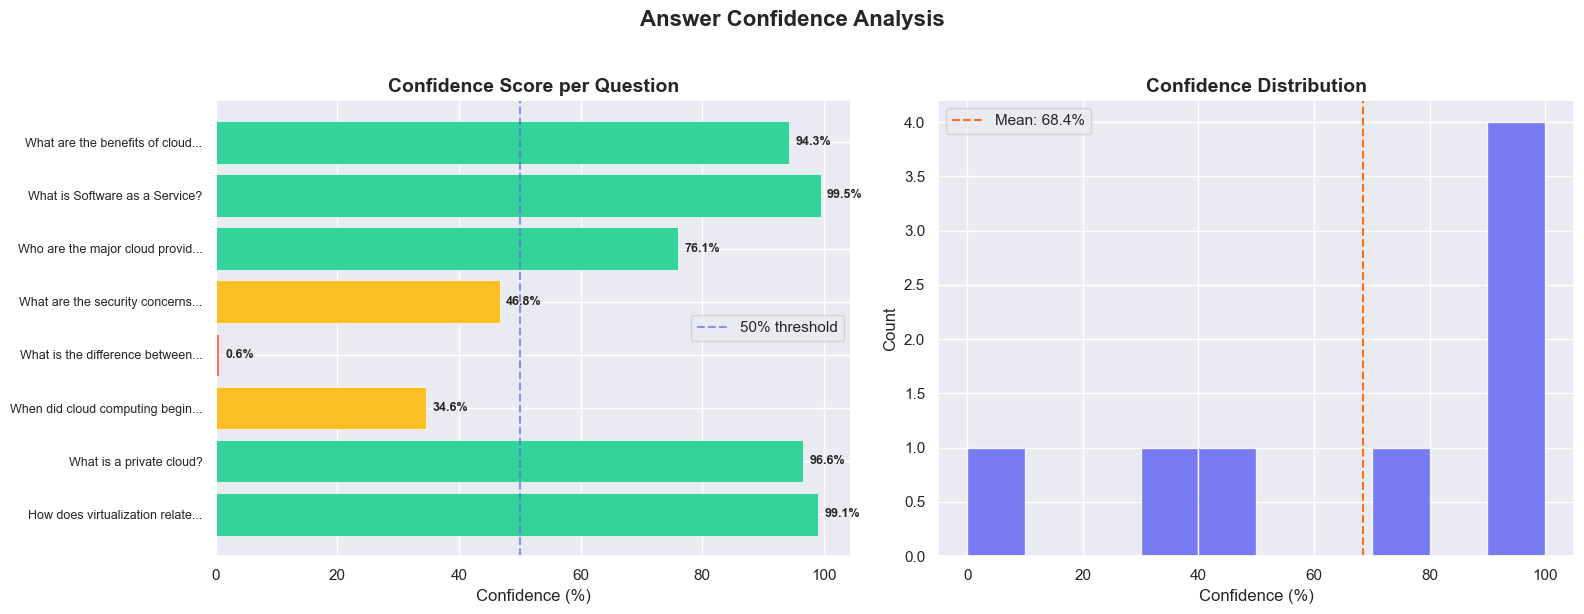

In [28]:
# ============================================================
# 7b. 📊 Confidence score distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of confidence per question
q_labels = [q[:30] + "..." if len(q) > 30 else q for q in questions]
colors_conf = ["#34d399" if c > 0.5 else "#fbbf24" if c > 0.3 else "#f87171" for c in confidences]

bars = axes[0].barh(range(len(confidences)), [c*100 for c in confidences],
                     color=colors_conf, edgecolor="white", linewidth=0.5)
axes[0].set_yticks(range(len(q_labels)))
axes[0].set_yticklabels(q_labels, fontsize=9)
axes[0].set_xlabel("Confidence (%)")
axes[0].set_title("Confidence Score per Question", fontweight="bold")
axes[0].axvline(x=50, color="#6366f1", linestyle="--", alpha=0.7, label="50% threshold")
axes[0].invert_yaxis()
axes[0].legend()

# Add value labels
for i, (bar, conf) in enumerate(zip(bars, confidences)):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f"{conf*100:.1f}%", va="center", fontsize=9, fontweight="bold")

# Histogram of confidence distribution
axes[1].hist([c*100 for c in confidences], bins=10, range=(0, 100),
             color="#6366f1", edgecolor="white", alpha=0.85)
axes[1].axvline(x=np.mean(confidences)*100, color="#f97316", linestyle="--",
                label=f"Mean: {np.mean(confidences)*100:.1f}%")
axes[1].set_xlabel("Confidence (%)")
axes[1].set_ylabel("Count")
axes[1].set_title("Confidence Distribution", fontweight="bold")
axes[1].legend()

plt.suptitle("Answer Confidence Analysis", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

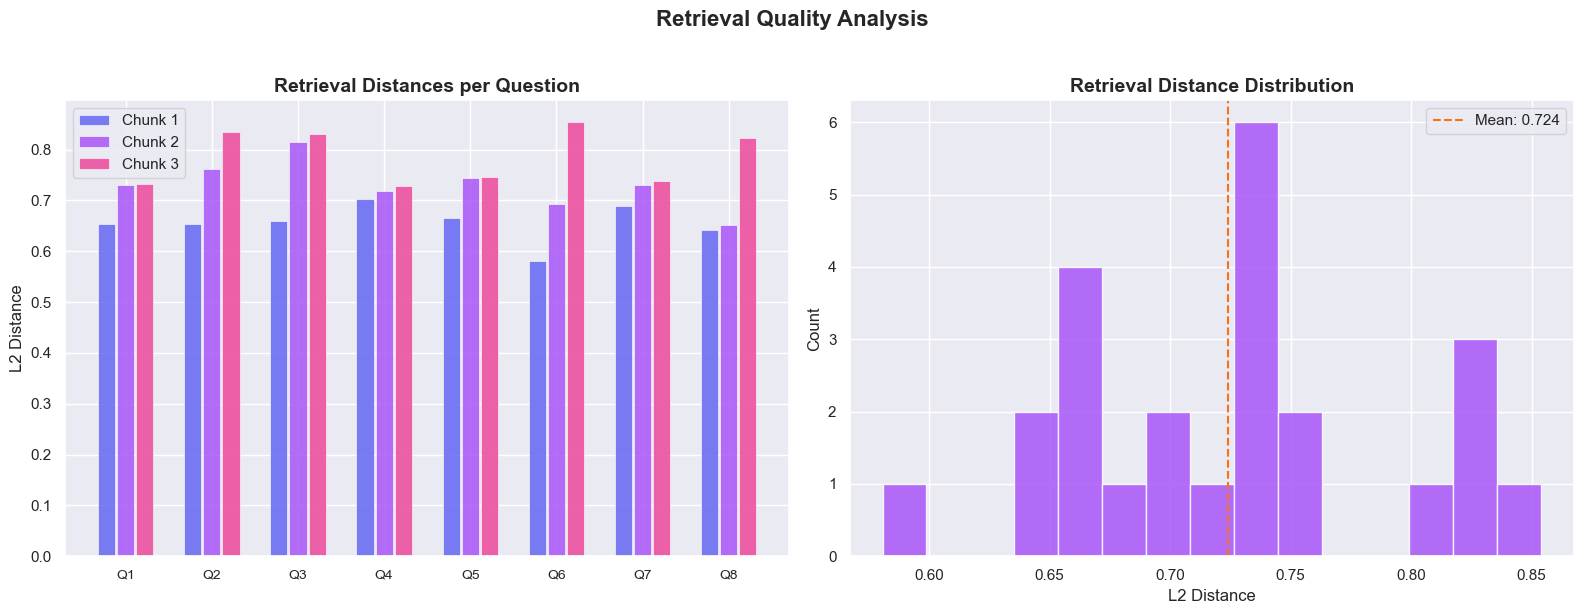


📊 Retrieval Distance Stats
   Mean distance    : 0.7242
   Min distance     : 0.5806  (best match)
   Max distance     : 0.8539  (worst match)
   Std deviation    : 0.0690


In [29]:
# ============================================================
# 7c. 📊 Retrieval distance analysis
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distances per question (grouped bar)
for i, r in enumerate(all_results):
    dists = [c["distance"] for c in r["retrieved_chunks"]]
    x_positions = [i * 0.9 + j * 0.2 for j in range(len(dists))]
    colors_bar = ["#6366f1", "#a855f7", "#ec4899"]
    for j, (xp, d) in enumerate(zip(x_positions, dists)):
        label = f"Chunk {j+1}" if i == 0 else None
        axes[0].bar(xp, d, width=0.18, color=colors_bar[j % 3], alpha=0.85,
                    edgecolor="white", linewidth=0.5, label=label)

axes[0].set_xticks([i * 0.9 + 0.2 for i in range(len(all_results))])
axes[0].set_xticklabels([f"Q{i+1}" for i in range(len(all_results))], fontsize=10)
axes[0].set_ylabel("L2 Distance")
axes[0].set_title("Retrieval Distances per Question", fontweight="bold")
axes[0].legend()

# Overall distance distribution
axes[1].hist(retrieval_distances, bins=15, color="#a855f7", edgecolor="white", alpha=0.85)
axes[1].axvline(x=np.mean(retrieval_distances), color="#f97316", linestyle="--",
                label=f"Mean: {np.mean(retrieval_distances):.3f}")
axes[1].set_xlabel("L2 Distance")
axes[1].set_ylabel("Count")
axes[1].set_title("Retrieval Distance Distribution", fontweight="bold")
axes[1].legend()

plt.suptitle("Retrieval Quality Analysis", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📊 Retrieval Distance Stats")
print(f"   Mean distance    : {np.mean(retrieval_distances):.4f}")
print(f"   Min distance     : {np.min(retrieval_distances):.4f}  (best match)")
print(f"   Max distance     : {np.max(retrieval_distances):.4f}  (worst match)")
print(f"   Std deviation    : {np.std(retrieval_distances):.4f}")

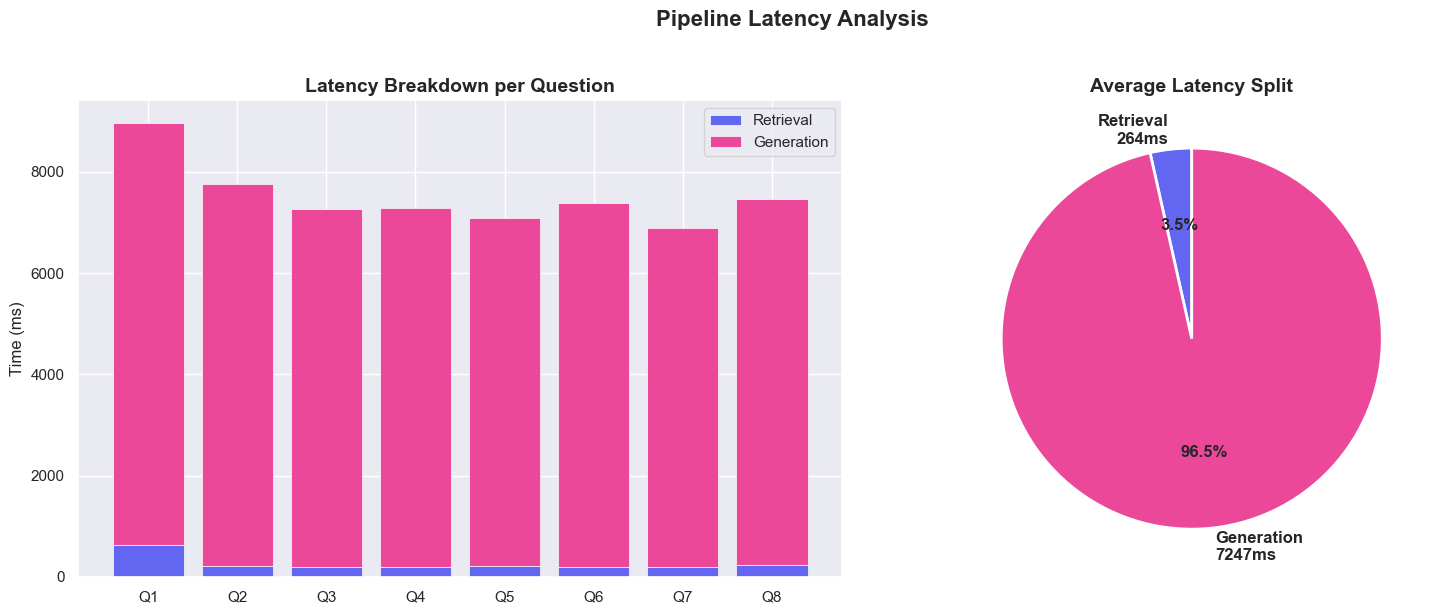


📊 Latency Summary
   Avg retrieval time  : 264 ms
   Avg generation time : 7247 ms
   Avg total time      : 7511 ms
   Generation share    : 96.5%


In [30]:
# ============================================================
# 7d. 📊 Latency breakdown (retrieval vs generation)
# ============================================================
retrieval_times = [r["retrieval_time"] * 1000 for r in all_results]
generation_times = [r["generation_time"] * 1000 for r in all_results]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar: retrieval vs generation time
x = range(len(all_results))
axes[0].bar(x, retrieval_times, label="Retrieval", color="#6366f1", edgecolor="white", linewidth=0.5)
axes[0].bar(x, generation_times, bottom=retrieval_times, label="Generation",
            color="#ec4899", edgecolor="white", linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"Q{i+1}" for i in x])
axes[0].set_ylabel("Time (ms)")
axes[0].set_title("Latency Breakdown per Question", fontweight="bold")
axes[0].legend()

# Pie chart: average time split
avg_ret = np.mean(retrieval_times)
avg_gen = np.mean(generation_times)
axes[1].pie([avg_ret, avg_gen], labels=[f"Retrieval\n{avg_ret:.0f}ms", f"Generation\n{avg_gen:.0f}ms"],
            colors=["#6366f1", "#ec4899"], autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 12, "fontweight": "bold"},
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Average Latency Split", fontweight="bold")

plt.suptitle("Pipeline Latency Analysis", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📊 Latency Summary")
print(f"   Avg retrieval time  : {avg_ret:.0f} ms")
print(f"   Avg generation time : {avg_gen:.0f} ms")
print(f"   Avg total time      : {avg_ret + avg_gen:.0f} ms")
print(f"   Generation share    : {avg_gen / (avg_ret + avg_gen) * 100:.1f}%")

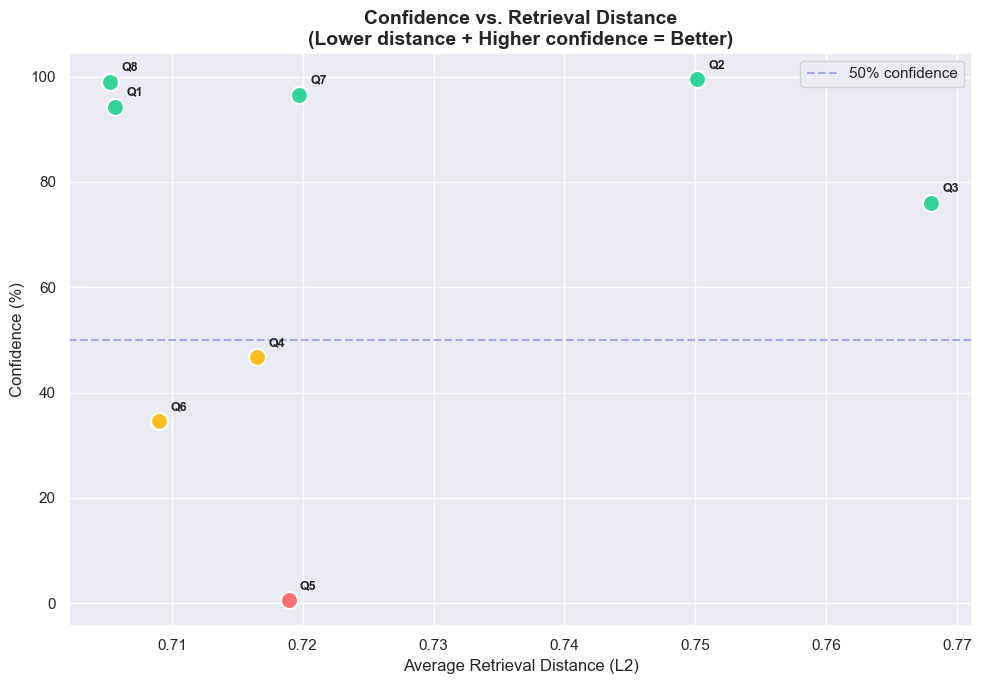

In [31]:
# ============================================================
# 7e. 📊 Confidence vs Retrieval Distance (scatter)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 7))

for i, r in enumerate(all_results):
    avg_dist = np.mean([c["distance"] for c in r["retrieved_chunks"]])
    conf = r["confidence"] * 100
    color = "#34d399" if conf > 50 else "#fbbf24" if conf > 30 else "#f87171"
    ax.scatter(avg_dist, conf, c=color, s=150, edgecolors="white", linewidth=1.5, zorder=5)
    ax.annotate(f"Q{i+1}", (avg_dist, conf), textcoords="offset points",
                xytext=(8, 8), fontsize=9, fontweight="bold")

ax.set_xlabel("Average Retrieval Distance (L2)", fontsize=12)
ax.set_ylabel("Confidence (%)", fontsize=12)
ax.set_title("Confidence vs. Retrieval Distance\n(Lower distance + Higher confidence = Better)",
             fontweight="bold", fontsize=14)
ax.axhline(y=50, color="#6366f1", linestyle="--", alpha=0.5, label="50% confidence")
ax.legend()
plt.tight_layout()
plt.show()

🔬 Testing Top-K values: [1, 2, 3, 5, 7, 10]
   Question: "What are the benefits of cloud computing?"

   K=1   → Conf:  96.8%  |  Time:   2647ms  |  Answer: lower costs, improved cost transparency and predictability
   K=2   → Conf:  94.3%  |  Time:   6794ms  |  Answer: lower costs, improved cost transparency and predictability
   K=3   → Conf:  94.3%  |  Time:   8564ms  |  Answer: lower costs, improved cost transparency and predictability
   K=5   → Conf:  94.3%  |  Time:  12719ms  |  Answer: lower costs, improved cost transparency and predictability
   K=7   → Conf:  94.3%  |  Time:  18155ms  |  Answer: lower costs, improved cost transparency and predictability
   K=10  → Conf:  94.3%  |  Time:  27487ms  |  Answer: lower costs, improved cost transparency and predictability


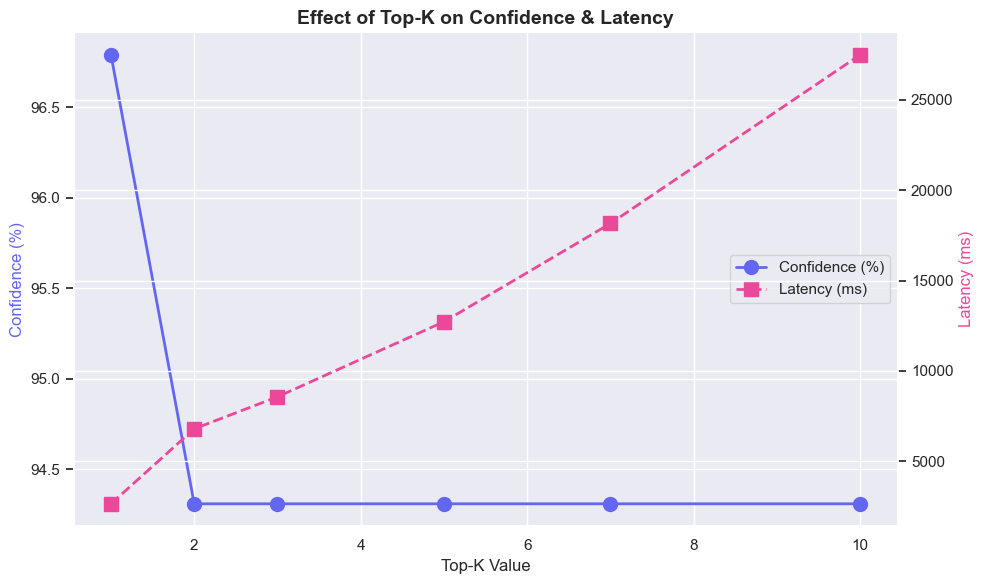

In [32]:
# ============================================================
# 7f. 📊 Effect of Top-K on answer quality
# ============================================================
test_question = "What are the benefits of cloud computing?"
k_values = [1, 2, 3, 5, 7, 10]
k_confidences = []
k_latencies = []
k_answers = []

print(f"🔬 Testing Top-K values: {k_values}")
print(f"   Question: \"{test_question}\"\n")

for k in k_values:
    if k > len(chunks):
        break
    res = rag_query(test_question, top_k=k, verbose=False)
    k_confidences.append(res["confidence"])
    k_latencies.append(res["total_time"] * 1000)
    k_answers.append(res["answer"])
    print(f"   K={k:<3} → Conf: {res['confidence']*100:5.1f}%  |  Time: {res['total_time']*1000:6.0f}ms  |  Answer: {res['answer'][:60]}")

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

valid_k = k_values[:len(k_confidences)]
ax1.plot(valid_k, [c*100 for c in k_confidences], "o-", color="#6366f1",
         linewidth=2, markersize=10, label="Confidence (%)")
ax2.plot(valid_k, k_latencies, "s--", color="#ec4899",
         linewidth=2, markersize=10, label="Latency (ms)")

ax1.set_xlabel("Top-K Value")
ax1.set_ylabel("Confidence (%)", color="#6366f1")
ax2.set_ylabel("Latency (ms)", color="#ec4899")
ax1.set_title("Effect of Top-K on Confidence & Latency", fontweight="bold", fontsize=14)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# 7g. 📊 Final validation report
# ============================================================
print("\n" + "=" * 70)
print(" 📋  FINAL RAG PIPELINE VALIDATION REPORT")
print("=" * 70)

print(f"\n🔧 Configuration")
print(f"   Topic              : {page_title}")
print(f"   Embedding model    : {EMBEDDING_MODEL_NAME}")
print(f"   QA model           : {QA_MODEL_NAME}")
print(f"   Chunk size/overlap : {CHUNK_SIZE} / {CHUNK_OVERLAP} tokens")
print(f"   Top-K              : {TOP_K}")

print(f"\n📄 Knowledge Base")
print(f"   Document length    : {len(document):,} characters")
print(f"   Total tokens       : {len(all_tokens):,}")
print(f"   Number of chunks   : {len(chunks)}")
print(f"   Embedding dim      : {dimension}")
print(f"   Index type         : FAISS IndexFlatL2")

print(f"\n📊 Answer Quality ({len(all_results)} questions)")
print(f"   Mean confidence    : {np.mean(confidences)*100:.1f}%")
print(f"   Max confidence     : {np.max(confidences)*100:.1f}%")
print(f"   Min confidence     : {np.min(confidences)*100:.1f}%")
print(f"   High conf (>50%)   : {sum(1 for c in confidences if c > 0.5)}/{len(confidences)}")
print(f"   Medium conf (30-50): {sum(1 for c in confidences if 0.3 < c <= 0.5)}/{len(confidences)}")
print(f"   Low conf (<30%)    : {sum(1 for c in confidences if c <= 0.3)}/{len(confidences)}")

print(f"\n🔍 Retrieval Quality")
print(f"   Mean L2 distance   : {np.mean(retrieval_distances):.4f}")
print(f"   Std L2 distance    : {np.std(retrieval_distances):.4f}")
print(f"   Best match dist.   : {np.min(retrieval_distances):.4f}")
print(f"   Worst match dist.  : {np.max(retrieval_distances):.4f}")

print(f"\n⏱️  Latency")
print(f"   Avg retrieval      : {np.mean(retrieval_times):.0f} ms")
print(f"   Avg generation     : {np.mean(generation_times):.0f} ms")
print(f"   Avg total          : {np.mean(latencies)*1000:.0f} ms")

# Error analysis
low_conf = [(i+1, r["question"], r["confidence"]) for i, r in enumerate(all_results) if r["confidence"] < 0.3]
if low_conf:
    print(f"\n⚠️  Low-Confidence Answers (potential errors):")
    for q_num, q_text, conf in low_conf:
        print(f"   Q{q_num}: {q_text[:50]:50s} → {conf*100:.1f}%")
else:
    print(f"\n✅ No low-confidence answers detected!")

print(f"\n{'='*70}")
print(f"  Pipeline Status: {'✅ OPERATIONAL' if np.mean(confidences) > 0.3 else '⚠️  NEEDS TUNING'}")
print(f"{'='*70}")


 📋  FINAL RAG PIPELINE VALIDATION REPORT

🔧 Configuration
   Topic              : Cloud computing
   Embedding model    : sentence-transformers/all-mpnet-base-v2
   QA model           : deepset/roberta-base-squad2
   Chunk size/overlap : 256 / 20 tokens
   Top-K              : 3

📄 Knowledge Base
   Document length    : 38,745 characters
   Total tokens       : 7,343
   Number of chunks   : 32
   Embedding dim      : 768
   Index type         : FAISS IndexFlatL2

📊 Answer Quality (8 questions)
   Mean confidence    : 68.4%
   Max confidence     : 99.5%
   Min confidence     : 0.6%
   High conf (>50%)   : 5/8
   Medium conf (30-50): 2/8
   Low conf (<30%)    : 1/8

🔍 Retrieval Quality
   Mean L2 distance   : 0.7242
   Std L2 distance    : 0.0690
   Best match dist.   : 0.5806
   Worst match dist.  : 0.8539

⏱️  Latency
   Avg retrieval      : 264 ms
   Avg generation     : 7247 ms
   Avg total          : 7511 ms

⚠️  Low-Confidence Answers (potential errors):
   Q5: What is the differe

---
## 🎯 Interactive Query Cell

Use the cell below to ask your own questions about the indexed topic.

In [35]:
# ============================================================
# 🎯 Ask your own question!
# ============================================================
your_question = "What is a hybrid cloud?"  # ← Change this to any question

result = rag_query(your_question)

print(f"\n📄 Retrieved Context (first chunk):")
print(f"   {result['retrieved_chunks'][0]['chunk'][:300]}...")


❓ Question   : What is a hybrid cloud?
💡 Answer     : a composition of a public
📊 Confidence : 96.8%
⏱️  Retrieval  : 218ms
⏱️  Generation : 7022ms
⏱️  Total      : 7240ms
📄 Windows    : 2

📄 Retrieved Context (first chunk):
   on - premises solution. = = = hybrid = = = hybrid cloud is a composition of a public cloud and a private environment, such as a private cloud or on - premises resources, that remain distinct entities but are bound together, offering the benefits of multiple deployment models. hybrid cloud can also m...
